In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
df = pd.read_csv("transactions.csv")

In [39]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

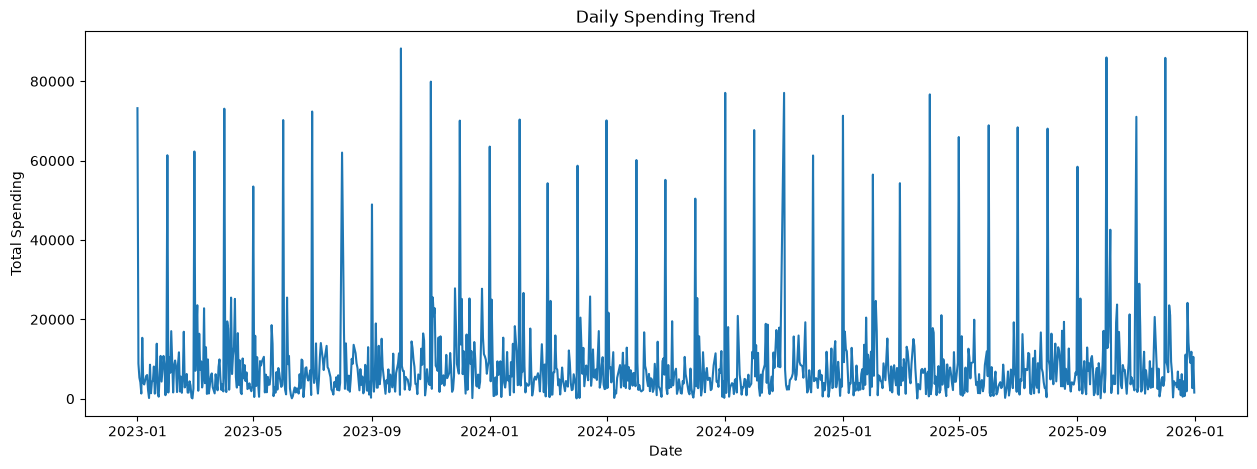

In [40]:
daily_spending = df.groupby("date")["amount"].sum()

plt.figure(figsize=(15,5))
plt.plot(daily)
plt.title("Daily Spending Trend")
plt.xlabel("Date")
plt.ylabel("Total Spending")
plt.show()

In [41]:
#normalize
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    daily_spending.values.reshape(-1, 1)
)

In [43]:
sequence_length = 30

X = []  
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)


In [45]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (805, 30, 1)
Testing Samples: (202, 30, 1)


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(30, 1)
    )
)
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

In [48]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0205 - val_loss: 0.0215
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0194 - val_loss: 0.0214
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0194 - val_loss: 0.0215
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0192 - val_loss: 0.0212
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0191 - val_loss: 0.0213
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0189 - val_loss: 0.0216
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0191 - val_loss: 0.0220
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0187 - val_loss: 0.0208
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0189 - val_loss: 0.0209
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0187 - val_loss: 0.0205
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0183 - val_loss: 0.0211
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

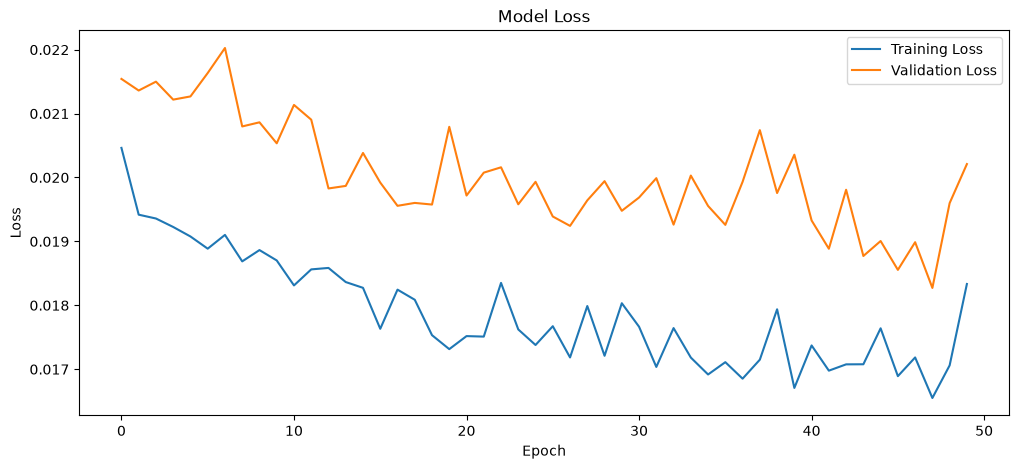

In [52]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [53]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [57]:
print(predictions.shape)

(202, 1)


In [56]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np
mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 722745309.1820792
MSE : 5.431107433526824e+17
RMSE: 736960476.1129882


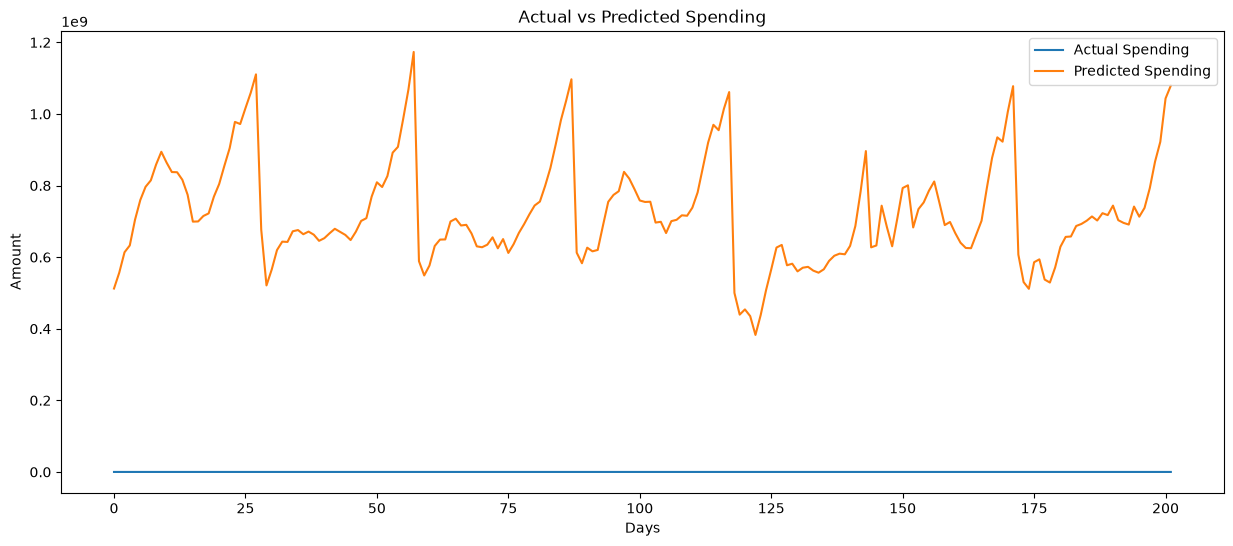

In [59]:
plt.figure(figsize=(15,6))

plt.plot(actual, label="Actual Spending")

plt.plot(predictions, label="Predicted Spending")

plt.title("Actual vs Predicted Spending")

plt.xlabel("Days")

plt.ylabel("Amount")

plt.legend()

plt.show()

In [61]:
last_sequence = scaled_data[-30:]

last_sequence = last_sequence.reshape(1,30,1)

next_day = model.predict(last_sequence)

next_day = scaler.inverse_transform(next_day)

print("Predicted Spending Tomorrow: ₹", next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Spending Tomorrow: ₹ 10284.602
